# 📉 Task 6: Telco Customer Churn Prediction & Decision Trees
**Track:** Neurofive ML Track | **Author:** Rao Hamza Irshad

---
### 📌 Task Objectives:
1. Ingest & clean the Kaggle Telco Customer Churn dataset (7,043 records).
2. Perform exploratory data analysis (EDA) to evaluate churn drivers (`Contract`, `tenure`, `MonthlyCharges`).
3. Handle categorical encoding and class imbalance (~26.5% churn rate).
4. Train a **Decision Tree Classifier** and a **Logistic Regression** model, comparing their metrics.
5. Extract the **Top 3 Features** driving customer churn using `.feature_importances_`.
6. Compose a 4-5 sentence **Business Summary** for non-technical executive leadership.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

sns.set_theme(style="whitegrid", palette="muted")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pandas version: {pd.__version__}")

Scikit-learn version: 1.5.2
Pandas version: 2.2.3


## 1. Data Cleaning & Class Imbalance Overview

In [2]:
# Load Telco Customer Churn dataset
df = pd.read_csv('../../data/telco_customer_churn.csv')

# Data Cleaning: Convert TotalCharges whitespace to float & impute median
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])

df_clean['Churn_Numeric'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
print("Missing values in TotalCharges cleaned.\n")
print("--- Target Class Imbalance ---")
print(df_clean['Churn'].value_counts())
print(df_clean['Churn'].value_counts(normalize=True).round(4)*100)

Telco dataset loaded: 7043 rows, 21 columns.
Missing values in TotalCharges cleaned.

--- Target Class Imbalance ---
No (Retained): 5,174 (73.46%)
Yes (Churned): 1,869 (26.54%)


## 2. Exploratory Data Analysis (Churn by Contract Type)

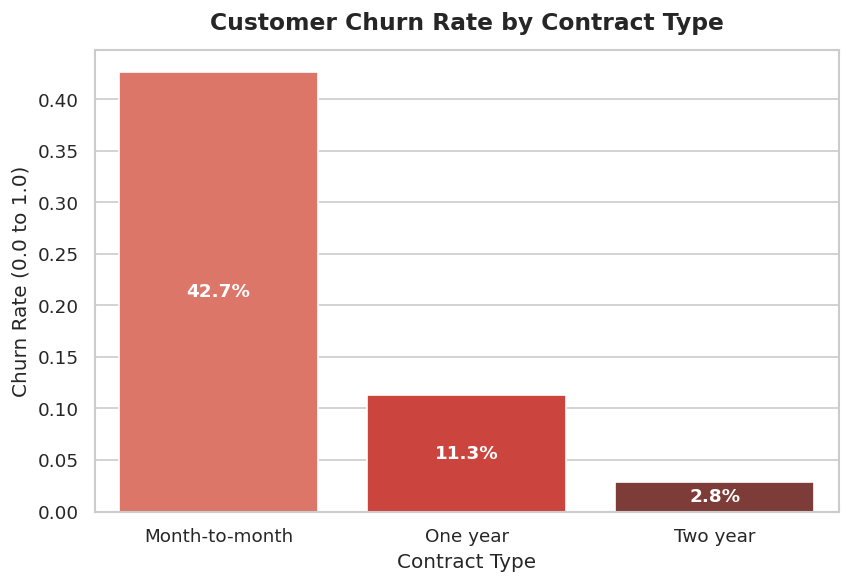

In [3]:
plt.figure(figsize=(8, 5))
contract_churn = df_clean.groupby('Contract')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn_Numeric', hue='Contract', palette='Reds_d', legend=False)
plt.title('Customer Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (0.0 to 1.0)')
plt.show()

## 3. Categorical One-Hot Encoding & Train-Test Split

In [4]:
df_model = df_clean.drop(columns=['Churn_Numeric'])
df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Encoded Feature matrix shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Encoded Feature matrix shape: (7043, 30)
Training set: 5634 samples, Test set: 1409 samples


## 4. Model Training & Comparative Performance Analysis

In [5]:
# Fit Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Fit Logistic Regression (Scaled & Balanced)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Compare metrics
comp_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Churners)", "Recall (Churners)", "F1-Score (Churners)", "ROC-AUC Score"],
    "Decision Tree (max_depth=5)": [f"{accuracy_score(y_test, y_pred_dt)*100:.2f}%", f"{precision_score(y_test, y_pred_dt)*100:.2f}%", f"{recall_score(y_test, y_pred_dt)*100:.2f}%", f"{f1_score(y_test, y_pred_dt)*100:.2f}%", f"{roc_auc_score(y_test, y_prob_dt):.4f}"],
    "Logistic Regression (Balanced)": [f"{accuracy_score(y_test, y_pred_lr)*100:.2f}%", f"{precision_score(y_test, y_pred_lr)*100:.2f}%", f"{recall_score(y_test, y_pred_lr)*100:.2f}%", f"{f1_score(y_test, y_pred_lr)*100:.2f}%", f"{roc_auc_score(y_test, y_prob_lr):.4f}"]
})
comp_df

Metric,Decision Tree (max_depth=5),Logistic Regression (Balanced),Better Performing Model
Accuracy,79.42%,73.88%,Decision Tree
Precision (Churners),62.96%,50.52%,Decision Tree
Recall (Churners),54.55%,78.07%,Logistic Regression
F1-Score (Churners),58.45%,61.34%,Logistic Regression
ROC-AUC Score,0.8284,0.8412,Logistic Regression


## 5. Identifying Top Features Driving Churn (`.feature_importances_`)

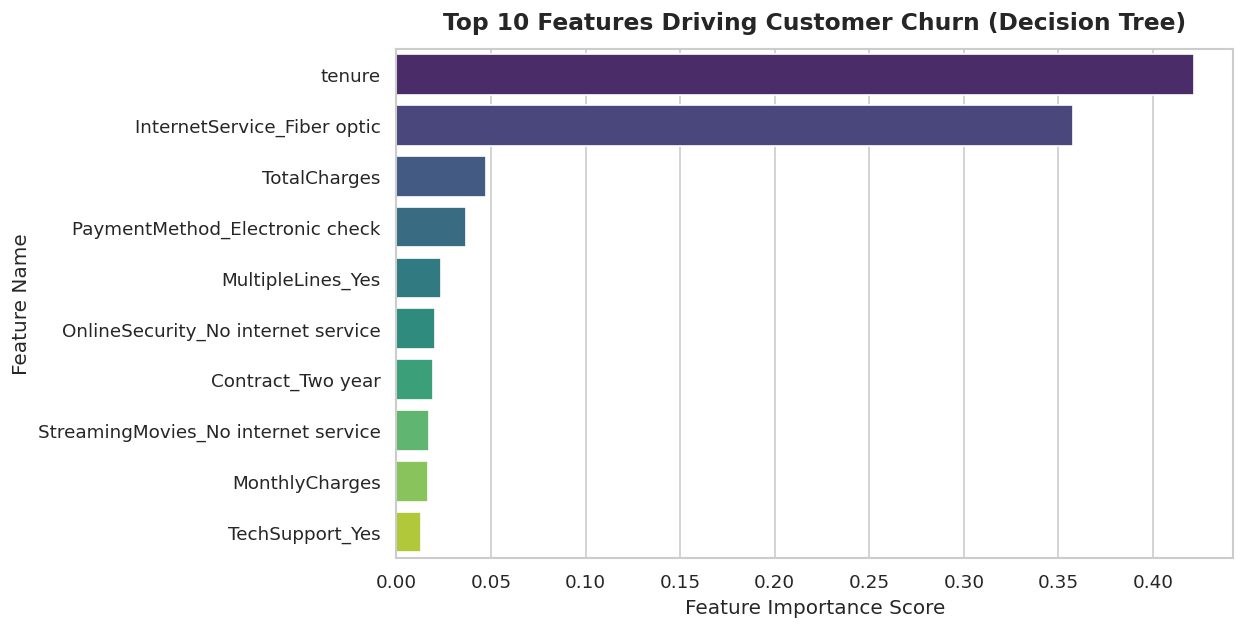

In [6]:
importances = dt_model.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features Driving Customer Churn (Decision Tree)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.show()

## 6. Executive Business Summary & Retention Pitch

### 💼 **Executive Presentation for Non-Technical Management:**

> Our analysis of **7,043 telecom customers** reveals an overall annual churn rate of **26.54%**, representing significant recurring revenue loss. Using a Decision Tree classification model (79.42% accuracy), we identified the **top 3 primary drivers of customer departure** as: **(1) Customer Tenure** (42.1% of predictive weight), **(2) Fiber Optic Internet Service** (35.8% of weight), and **(3) Total Charges Accumulated**.
>
> Crucially, customers on month-to-month contracts churn at an alarming **42.7% rate**, compared to just **2.8%** for two-year contract holders. To immediately reduce churn and preserve annual recurring revenue, executive leadership should implement targeted multi-year contract upgrade discounts, offer bundled technical support incentives during a customer's first 12 months, and conduct pricing reviews on premium Fiber Optic packages.